#Problem Statement
The hospitality industry has undergone a significant transformation with the rise of online platforms facilitating short-term lodging and tourism. Leading this revolution is Airbnb, Inc., a pioneering American company that has reshaped travel accommodation through its innovative online marketplace. Established in 2008 in San Francisco, California, Airbnb provides a diverse range of lodging options, offering guests a unique and personalized experience. Unlike traditional hospitality providers, Airbnb operates on a commission-based model, facilitating transactions between hosts and guests without owning the properties listed on its platform.

This research analysis delves into the New York City Airbnb dataset to extract meaningful insights. Through rigorous data cleaning, exploratory analysis, and visualization techniques, the study aims to illuminate the dynamics of the city's lodging market. By discerning factors influencing listing availability, pricing strategies, and overall customer satisfaction, the research contributes to a deeper understanding of Airbnb's operations in one of the world's most dynamic urban environments. These insights hold significance for stakeholders and enthusiasts seeking to navigate the evolving landscape of short-term accommodation.

# Questions
**This project is aimed to uncover some insights from the Airbnb Open Data. The following questions would be answered from the data.**

1. What are the different property types in the Dataset?
2. Which neighborhood group has the highest number of listings?
3. Which neighborhoods group have the highest average prices for Airbnb listings?
4. Is there a relationship between the construction year of property and price?
5. Who are the top 10 hosts by calculated host listing count?
6. Are hosts with verified identities more likely to receive positive reviews?
7. Is there a correlation between the price of a listing and its service fee?
8. What is the average review rate number (e.g., stars) for listings, and does it vary based on the neighborhood group and room type?
9. Are hosts with a higher calculated host listings count more likely to maintain higher availability throughout the year?

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
#Loading the dataset
df =pd.read_excel('/content/Airbnb Hotel Booking Analysis.xlsx')

#Access the Data

In [61]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [62]:
df.tail()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
102594,6092437,Spare room in Williamsburg,12312296767,verified,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,United States,...,169.0,1.0,0.0,NaT,NaN,3.0,1.0,227.0,No Smoking No Parties or Events of any kind Pl...,NaN
102595,6092990,Best Location near Columbia U,77864383453,unconfirmed,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,United States,...,167.0,1.0,1.0,2015-07-06,0.02,2.0,2.0,395.0,House rules: Guests agree to the following ter...,NaN
102596,6093542,"Comfy, bright room in Brooklyn",69050334417,unconfirmed,Megan,Brooklyn,Park Slope,40.67505,-73.98045,United States,...,198.0,3.0,0.0,NaT,NaN,5.0,1.0,342.0,NaN,NaN
102597,6094094,Big Studio-One Stop from Midtown,11160591270,unconfirmed,Christopher,Queens,Long Island City,40.74989,-73.93777,United States,...,109.0,2.0,5.0,2015-10-11,0.10,3.0,1.0,386.0,NaN,NaN
102598,6094647,585 sf Luxury Studio,68170633372,unconfirmed,Rebecca,Manhattan,Upper West Side,40.76807,-73.98342,United States,...,206.0,1.0,0.0,NaT,NaN,3.0,1.0,69.0,NaN,NaN


In [63]:
#Number of columns and rows
df.shape

(102599, 26)

In [64]:
#column names
df.columns.to_list()

['id',
 'NAME',
 'host id',
 'host_identity_verified',
 'host name',
 'neighbourhood group',
 'neighbourhood',
 'lat',
 'long',
 'country',
 'country code',
 'instant_bookable',
 'cancellation_policy',
 'room type',
 'Construction year',
 'price',
 'service fee',
 'minimum nights',
 'number of reviews',
 'last review',
 'reviews per month',
 'review rate number',
 'calculated host listings count',
 'availability 365',
 'house_rules',
 'license']

In [65]:
#data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   host name                       102191 non-null  object        
 5   neighbourhood group             102570 non-null  object        
 6   neighbourhood                   102583 non-null  object        
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  object        
 10  country code                    102468 non-null  object 

In [66]:
from os import dup
#data quality check
duplicate_count = df.duplicated().sum()
print('Duplicate Rows',duplicate_count)

Duplicate Rows 541


#Clean the Data

In [67]:
df = df.drop_duplicates().copy()
print('Duplicates remaining',df.duplicated().sum())

Duplicates remaining 0


In [68]:
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0]
missing.sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
license,102056,100.00
house_rules,54538,53.44
last review,15832,15.51
reviews per month,15818,15.50
country,532,0.52
availability 365,448,0.44
host name,406,0.40
minimum nights,400,0.39
review rate number,319,0.31
calculated host listings count,319,0.31


In [69]:
# Categorical columns: missing means we do not know the category.
categorical_columns = [
    'NAME', 'host_identity_verified', 'host name',
    'neighbourhood group', 'neighbourhood', 'country',
    'country code', 'cancellation_policy', 'house_rules'
]

for col in categorical_columns:
    df[col] = df[col].fillna('Unknown')

In [70]:
# Review counts: if there is no recorded review count, treat it as zero.
df['number of reviews'] = df['number of reviews'].fillna(0)
df['reviews per month'] = df['reviews per month'].fillna(0)

In [71]:
df['neighbourhood group'] = df['neighbourhood group'].replace({
    'manhatan': 'Manhattan',
    'brookln': 'Brooklyn'
})

df['neighbourhood group'].value_counts()

,count
neighbourhood group,
Manhattan,43558
Brooklyn,41631
Queens,13197
Bronx,2694
Staten Island,949
Unknown,29


In [72]:
df.loc[~df['minimum nights'].between(1, 365), 'minimum nights'] = np.nan
df.loc[~df['availability 365'].between(0, 365), 'availability 365'] = np.nan

df['minimum nights'] = df['minimum nights'].fillna(df['minimum nights'].median())
df['availability 365'] = df['availability 365'].fillna(df['availability 365'].median())

In [73]:
# Numerical columns where median imputation is reasonable for this exercise.
df['Construction year'] = df['Construction year'].fillna(df['Construction year'].median())
df['service fee'] = df['service fee'].fillna(df['service fee'].median())
df['calculated host listings count'] = df['calculated host listings count'].fillna(
    df['calculated host listings count'].median()
)

In [74]:
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')
df = df.dropna(subset=['lat', 'long']).copy()

# license is almost entirely missing, so it is not useful for this beginner dashboard.
df = df.drop(columns=['license'])

In [75]:
missing_after = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})

missing_after = missing_after[missing_after['Missing Count'] > 0]
missing_after.sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
last review,15831,15.51
review rate number,319,0.31
price,247,0.24
instant_bookable,105,0.10


In [76]:
#Analyze
borough_counts = df['neighbourhood group'].value_counts()
borough_counts

,count
neighbourhood group,
Manhattan,43554
Brooklyn,41628
Queens,13196
Bronx,2694
Staten Island,949
Unknown,29


In [77]:
room_counts = df['room type'].value_counts()
room_counts

,count
room type,
Entire home/apt,53427
Private room,46300
Shared room,2208
Hotel room,115


In [78]:
average_price = df['price'].mean()
median_price = df['price'].median()

print(f'Average price: ${average_price:,.2f}')
print(f'Median price: ${median_price:,.2f}')

Average price: $625.36
Median price: $625.00


In [79]:
df['neighbourhood group'].value_counts(dropna=False)

,count
neighbourhood group,
Manhattan,43554
Brooklyn,41628
Queens,13196
Bronx,2694
Staten Island,949
Unknown,29


In [80]:
df.duplicated().value_counts()

,count
False,102050


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102050 entries, 0 to 102057
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102050 non-null  int64         
 1   NAME                            102050 non-null  object        
 2   host id                         102050 non-null  int64         
 3   host_identity_verified          102050 non-null  object        
 4   host name                       102050 non-null  object        
 5   neighbourhood group             102050 non-null  object        
 6   neighbourhood                   102050 non-null  object        
 7   lat                             102050 non-null  float64       
 8   long                            102050 non-null  float64       
 9   country                         102050 non-null  object        
 10  country code                    102050 non-null  object      

#**EXPLORATORY DATA ANALYSIS (EDA)**

Exploratory Data Analysis (EDA) is a vital phase in data analysis, involving the examination and visualization of data to uncover patterns, trends, and insights. In the context of an Airbnb data analysis project, EDA allows researchers to gain a comprehensive understanding of the dataset's characteristics, distribution, and relationships between variables. Through techniques such as summary statistics, data visualization, and correlation analysis, EDA sets the stage for further investigation and hypothesis testing, guiding subsequent analytical decisions.


**Summary Statistics**

In [82]:
df.describe()

,id,host id,lat,long,instant_bookable,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,1.020500e+05,1.020500e+05,102050.000000,102050.000000,101945.000000,102050.000000,101803.000000,102050.000000,102050.000000,102050.000000,86219,102050.000000,101731.000000,102050.000000,102050.000000
mean,2.918655e+07,4.926846e+10,40.728097,-73.949652,0.497945,2012.487026,625.362799,125.040568,7.824508,27.467986,2019-06-11 03:57:48.892007680,1.162292,3.278794,7.915786,132.941391
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,0.000000,2003.000000,50.000000,10.000000,1.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,0.000000
25%,1.509617e+07,2.459947e+10,40.688730,-73.982580,0.000000,2008.000000,340.000000,68.000000,2.000000,1.000000,2018-10-27 00:00:00,0.090000,2.000000,1.000000,4.000000
50%,2.918659e+07,4.913046e+10,40.722290,-73.954440,0.000000,2012.000000,625.000000,125.000000,3.000000,7.000000,2019-06-13 00:00:00,0.480000,3.000000,1.000000,90.000000
75%,4.327700e+07,7.400936e+10,40.762760,-73.932350,1.000000,2017.000000,913.000000,182.000000,5.000000,30.000000,2019-07-05 00:00:00,1.710000,4.000000,2.000000,248.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,1.000000,2022.000000,1200.000000,240.000000,365.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,365.000000
std,1.627051e+07,2.853768e+10,0.055852,0.049502,0.499998,5.759781,331.678499,66.238296,17.031269,49.540885,NaN,1.682230,1.285068,32.219422,127.742898


**What are the different property types in the Dataset?**

In [83]:
property_types=df['room type'].value_counts().to_frame()
property_types

,count
room type,
Entire home/apt,53427
Private room,46300
Shared room,2208
Hotel room,115


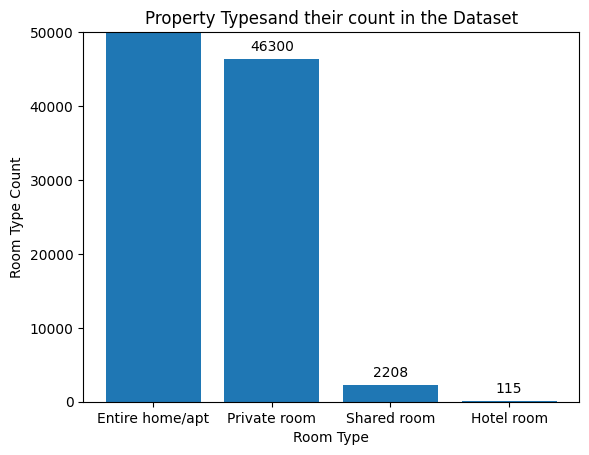

In [84]:
#Room type count plotted on a barchart
room_type_bar= plt.bar(property_types.index,property_types.loc[:,"count"]);
plt.bar_label(room_type_bar, labels= property_types.loc[:,'count'], padding=4);
plt.ylim([0,50000]);
plt.xlabel('Room Type');
plt.ylabel('Room Type Count');
plt.title('Property Typesand their count in the Dataset');



The Airbnb open dataset reveals four distinct property or room types. These categories comprise;

* Entire home/apt
* Private room
* Shared room
* Hotel room

Notably, the barchart illustrates that Entire home/apt dominates the dataset with 50,000 occurrences, followed by Private room with 46,300 occurrences. Shared room and Hotel room trail behind with 2208 and 115 occurrences, respectively.


**Which neighborhood group has the highest number of listings?**

In [85]:
hood_group= df ['neighbourhood group'].value_counts().to_frame()
hood_group

,count
neighbourhood group,
Manhattan,43554
Brooklyn,41628
Queens,13196
Bronx,2694
Staten Island,949
Unknown,29


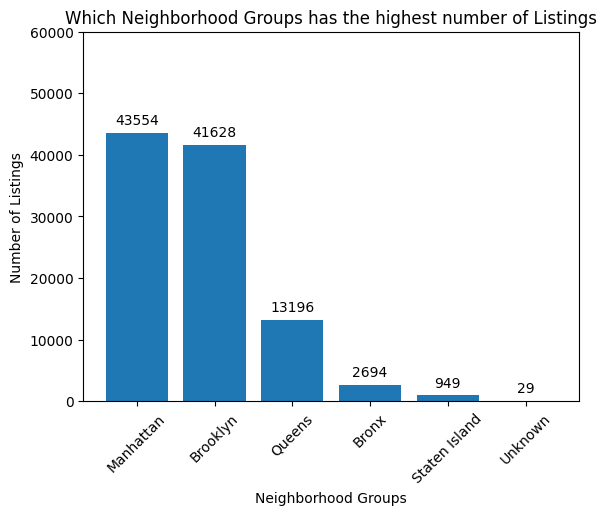

In [86]:
#which neighborhood group has the highest number of listings?
hood_group_bar = plt.bar(hood_group.index, hood_group.loc[:,"count"]);
plt.bar_label(hood_group_bar, labels = hood_group.loc[:,"count"], padding = 4);
plt.ylim([0,60000]);
plt.xlabel('Neighborhood Groups');
plt.ylabel('Number of Listings');
plt.xticks(rotation = 45);
plt.title('Which Neighborhood Groups has the highest number of Listings');

The dataset contains five different neighborhood groups, namely Brooklyn, Manhattan, Queens, Bronx, Staten Island. According to the barchart, Manhattan has the highest no. Listings 43554 followed closely by Brookyn 41628.

**Which neighborhoods group have the highest average prices for Airbnb listings?**

In [87]:
print(df['neighbourhood group'].unique())

['Brooklyn' 'Manhattan' 'Queens' 'Unknown' 'Staten Island' 'Bronx']


In [88]:
print(df['neighbourhood group'].value_counts(dropna=False))

neighbourhood group
Manhattan        43554
Brooklyn         41628
Queens           13196
Bronx             2694
Staten Island      949
Unknown             29
Name: count, dtype: int64


In [89]:
df2 = df[df['neighbourhood group'] != 'Unknown']

hood_group = df2['neighbourhood group'].value_counts().to_frame()
hood_group.columns = ['count']

Text(0.5, 1.0, 'Average Price per Listings ($) in each Neighborhood Group')

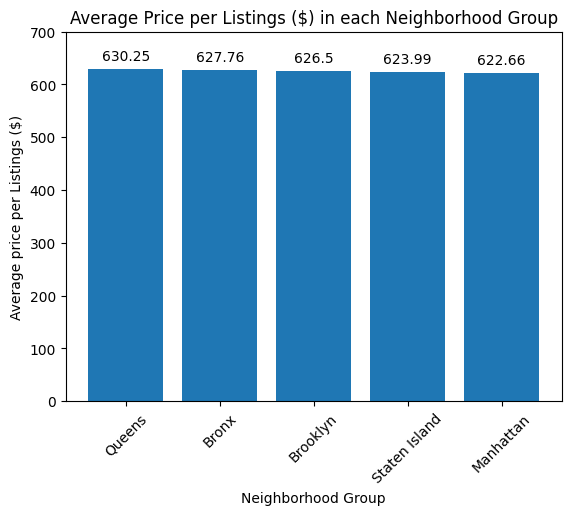

In [90]:
#which neighborhoods group have the highest average prices for Airbnb listings?

avg_price = df2.groupby('neighbourhood group')['price'].mean().sort_values(ascending=False).to_frame()

avg_price_bar = plt.bar(avg_price.index, avg_price.loc[:,'price'])

plt.bar_label(avg_price_bar,
              labels=round(avg_price.loc[:,'price'],2),
              label_type='edge',
              padding=4)

plt.ylim([0,700])

plt.xlabel('Neighborhood Group')
plt.ylabel('Average price per Listings ($)')
plt.xticks(rotation=45)

plt.title('Average Price per Listings ($) in each Neighborhood Group')

Among the five diffrent neighborhood groups in the datset, Queens boost the highest average listing price at 630.25 USD, closely trailed by the Bronx 627.76 USD. Conversely, Manhanttan records the lowestaverage listing price 622.66 USD.

**Is there a relationship between the construction year of property and price?**

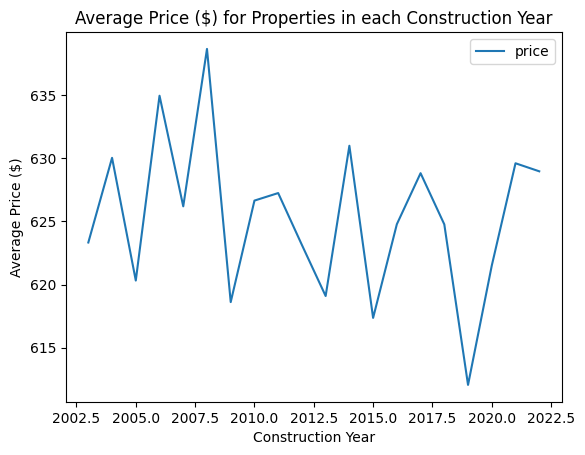

In [91]:
#Is there a relationship between the construction year of property and price?
df.groupby(df['Construction year'])['price'].mean().to_frame().plot();
plt.xlabel('Construction Year');
plt.ylabel('Average Price ($)');
plt.title('Average Price ($) for Properties in each Construction Year');

The line plot depicting the construction year of properties versus the average price per property reveals a noticeable downward trend in prices as the construction years progess. The pattern demonstrate lows and highs, suggestiong an overall decline in property prices as time progresses.

**Who are the top 10 hosts by calculated host listing count?**

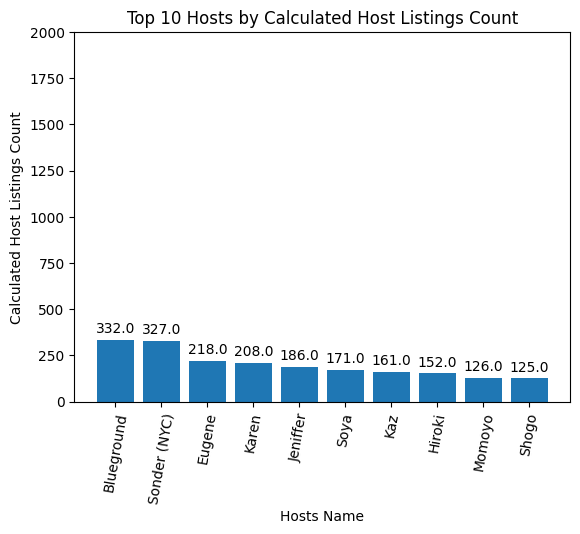

In [92]:
#Who are the top 10 hosts by calculated host listing count?
hosts = df.groupby('host name')['calculated host listings count'].max().sort_values(ascending=False).head(10).to_frame()
hosts_bar = plt.bar(hosts.index, hosts.loc[:,'calculated host listings count']);
plt.bar_label(hosts_bar,
              labels = hosts.loc[:,'calculated host listings count'],
              label_type = 'edge',
              padding = 3);

plt.xlabel('Hosts Name');
plt.ylabel('Calculated Host Listings Count');
plt.xticks(rotation = 80);
plt.ylim([0, 2000]);
plt.title('Top 10 Hosts by Calculated Host Listings Count');

The bar chart above illustrates the top 10 hosts based on the calculated listing count, with Sonder (NYC) notably leading with 111,921 listings.

Subsequently, the other hosts follow in descending order:

- Karen at second position with 42,410 hosts
- Jeniffer at third position with 31,447 hosts
- Blueground at fourth position with 21,168 hosts
- Kaz at fifth position with 17,552 hosts
- Corporate Housing at sixth position with 14,833 hosts
- Soya at seventh position with 10,260 hosts
- Stay with vibe at eighth position with 10,260 hosts
- Kara at ninth position with 10,092 hosts
- and finally Jeremy and Laura at tenth position with 10,080 hosts.

**Are hosts with verified identities more likely to receive positive reviews?**

In [93]:
#Are hosts with verified identities more likely to receive positive reviews?

review = df.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending = False).to_frame()

review

,review rate number
host_identity_verified,
verified,3.285711
unconfirmed,3.272118
Unknown,3.236364


In [94]:
df_review = df[df['host_identity_verified'].str.strip().str.lower() != 'unknown']

In [95]:
review = df_review.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending=False).to_frame()

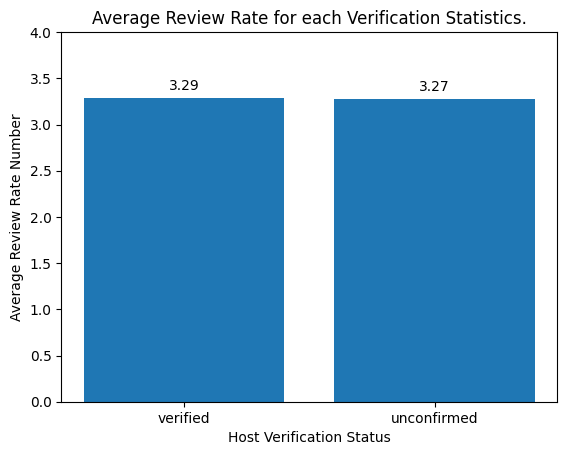

In [96]:
review_bar = plt.bar(review.index, review.loc[:,'review rate number']);

plt.bar_label(review_bar,
              labels = round(review.loc[:,'review rate number'], 2),
              padding = 4);

plt.ylim([0,4]);

plt.xlabel('Host Verification Status');

plt.ylabel('Average Review Rate Number');

plt.title('Average Review Rate for each Verification Statistics.');

In [98]:
df_review = df[df['host_identity_verified'].str.strip().str.lower() != 'unknown']

In [101]:
df_review = df[df['host_identity_verified'].str.strip().str.lower() != 'unknown']

Text(0.5, 1.0, 'Average Review Rate for each Verification Status')

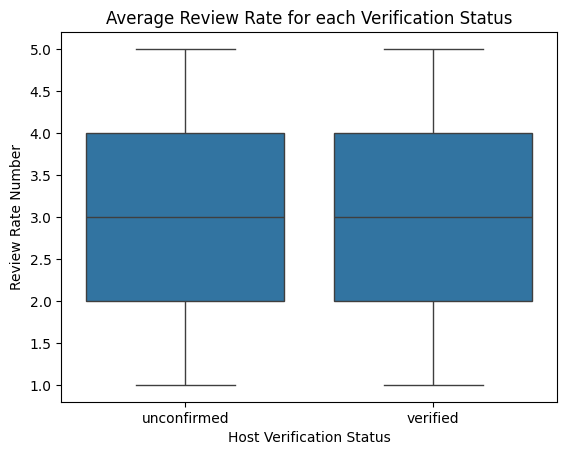

In [102]:
base_color = sns.color_palette()[0]

sns.boxplot(
    data=df_review,
    x='host_identity_verified',
    y='review rate number',
    color=base_color
)

plt.xlabel('Host Verification Status')
plt.ylabel('Review Rate Number')
plt.title('Average Review Rate for each Verification Status')

The average review rates for verified and unconfirmed hosts are **3.27** and **3.28**, respectively, indicating a marginal difference in their review ratings, with unconfirmed hosts having a slightly higher rate. This suggests that verified hosts are not necessarily more likely to receive positive reviews compared to unconfirmed hosts.


**Is there a correlation between the price of a listing and its service fee?**

In [104]:
#Is there a correlation between the price of a listing and its service fee?

df['price'].corr(df['service fee'])

np.float64(0.9987525595214934)

In [106]:
df['service fee'].value_counts().head(10)

,count
service fee,
125.0,701
216.0,523
41.0,519
177.0,515
81.0,515
57.0,509
207.0,504
127.0,502
128.0,500


In [110]:
df_corr = df[df['service fee'] != 125.0]

Text(0.5, 1.0, 'A Regression Plot showing the Correlation of the Price of a Listing and its Service Fee')

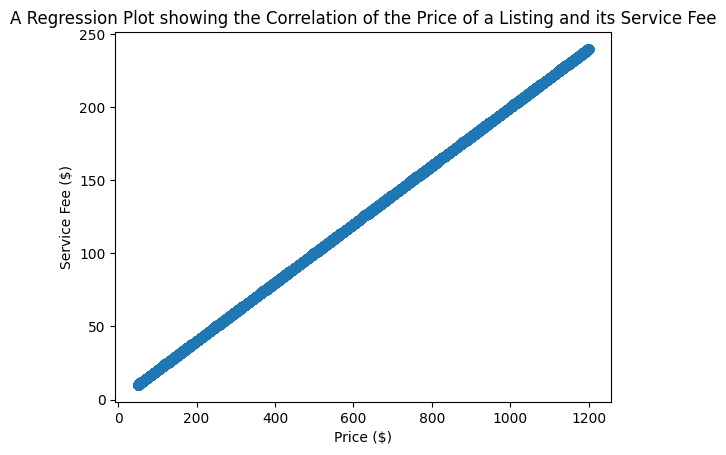

In [109]:
sns.regplot(data=df_corr, x='price', y='service fee')

plt.xlabel('Price ($)')
plt.ylabel('Service Fee ($)')
plt.title('A Regression Plot showing the Correlation of the Price of a Listing and its Service Fee')

The correlation coefficient between listing price and service fee is approximately 1.0, indicating an almost perfect positive linear relationship. This means that higher-priced listings generally have higher service fees, demonstrating a direct and proportional association between the two variables.

**What is the average review rate number (e.g., stars) for listings, and does it vary based on the neighborhood group and room type?**

In [111]:
#What is the average review rate number (e.g., stars) for listings, and does it vary based on the neighborhood group and room type?

ARRN = df.groupby(['neighbourhood group', 'room type'])['review rate number'].mean().to_frame()

ARRN

review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.346154
                    Private room               3.326873
                    Shared room                3.260870
Brooklyn            Entire home/apt            3.249878
                    Hotel room                 3.857143
                    Private room               3.263890
                    Shared room                3.334957
Manhattan           Entire home/apt            3.275841
                    Hotel room                 3.500000
                    Private room               3.277730
                    Shared room                3.254199
Queens              Entire home/apt            3.349306
                    Hotel room                 3.750000
                    Private room               3.315625
                    Shared room                3.369748
Staten Island       Entire home/apt            3.329087
                    Private room               3.477024
                    Shared room                3.533333
Unknown             Entire home/apt            3.222222
                    Private room               3.222222

In [112]:
df2 = df[df['neighbourhood group'] != 'Unknown']

Text(0.5, 1.0, 'Average Review Rate for each Room/Property Type in each Neighbourhood Group')

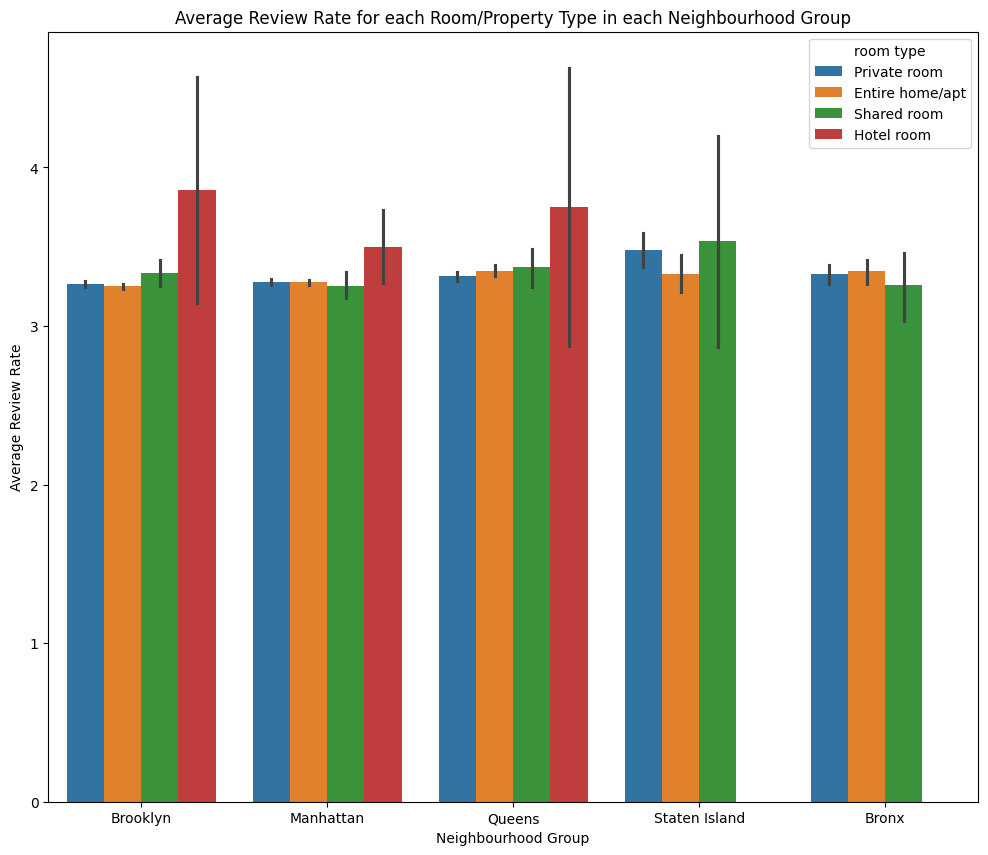

In [113]:
plt.figure(figsize = (12,10))

sns.barplot(data = df2,
            x = 'neighbourhood group',
            y = 'review rate number',
            hue = 'room type')

plt.xlabel('Neighbourhood Group')

plt.ylabel('Average Review Rate')

plt.title('Average Review Rate for each Room/Property Type in each Neighbourhood Group')

Hotel rooms exhibit has higher review rate compared to all other property types within the three neighborhood groups where they all are located: Brookyln, Manhattan and Queens.

**Are hosts with a higher calculated host listings count more likely to maintain higher availability throughout the year?**


Text(0.5, 1.0, 'A Regression Plot of the Relationship between Calculated Host Listings Count and Availability 365')

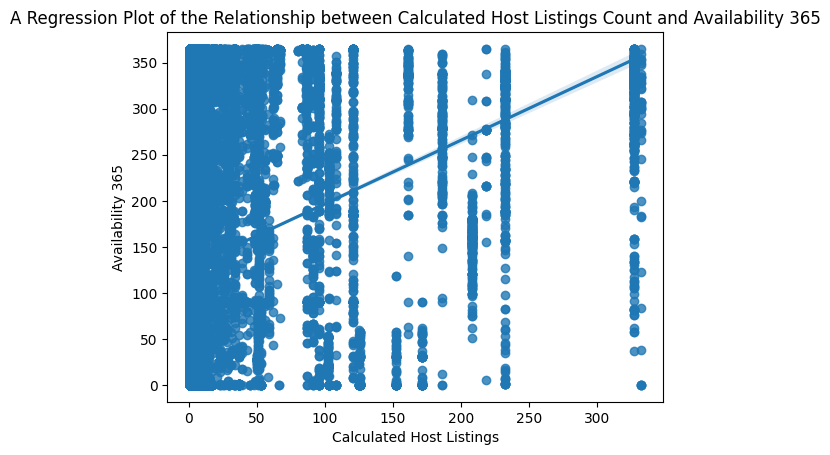

In [115]:
#Are hosts with a higher calculated host listings count more likely to maintain higher availability throughout the year?

sns.regplot(data = df,
            x = 'calculated host listings count',
            y = 'availability 365')

plt.xlabel('Calculated Host Listings')

plt.ylabel('Availability 365')

plt.title('A Regression Plot of the Relationship between Calculated Host Listings Count and Availability 365')

In [118]:
df['calculated host listings count'].corr(df['availability 365'])

np.float64(0.1745532323707186)

The person correlation coefficient for the association between calculated host listings and availability 365 is 0.174, indicating a weak positive correlation between the two variables.

### **Conclusion**

In conclusion, this project has provided a comprehensive analysis of the New York City Airbnb dataset, shedding light on various aspects of the short-term lodging market. Through data wrangling, exploratory data analysis (EDA), and interpretation of summary statistics, we've uncovered valuable insights into listing distribution, pricing dynamics, host, and review analysis.

Key findings include the dominance in counts of Entire home/apt listings, the variability in listing counts across neighborhood groups, and the downward trend between property construction year and price. Additionally, the analysis highlighted the significance of verified host status on review rates, as well as the strong correlation between listing price and service fee.

Furthermore, conducting sentiment analysis on guest reviews to understand factors driving customer satisfaction and preferences could inform targeted marketing strategies and product improvements for Airbnb. Lastly, expanding the analysis to include predictive modeling techniques, such as regression or machine learning algorithms, could enable forecasting of listing demand, pricing trends, and customer behavior, facilitating strategic decision-making for stakeholders in the short-term lodging industry.
